# Final Evaluation and Research Findings

## Student Performance Prediction and At-Risk Student Identification

This notebook consolidates the final findings from the student
performance machine learning project.

The evaluation combines the regression and classification experiments
and presents the final model performance, validation results,
comparisons, important predictive features, and research findings.

The analysis follows the project workflow of data understanding,
preprocessing, data mining and machine learning, evaluation,
validation, interpretation, and reporting.

## 1. Project Objective

The objective of this project is to investigate whether student
demographic, academic, family, social, and lifestyle characteristics
can be used to predict academic performance and identify students who
may be at risk of poor final academic performance.

Two machine learning tasks are considered:

1. Regression — prediction of the student's final grade.
2. Classification — identification of students at risk of poor final
   academic performance.

The classification task is particularly important because it provides
an early-warning perspective for identifying students who may require
additional academic support.

## 2. Research Question

Can machine learning techniques use student demographic, academic,
family, social, and lifestyle characteristics to predict academic
performance and identify students who are at risk of poor final
academic performance?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    KFold,
    cross_val_score
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

### Load the raw data

In [2]:
PROJECT_ROOT = Path.cwd().parent

FEATURES_PATH = (
    PROJECT_ROOT /
    "data" /
    "raw" /
    "student_performance_features.csv"
)

TARGETS_PATH = (
    PROJECT_ROOT /
    "data" /
    "raw" /
    "student_performance_targets.csv"
)

features = pd.read_csv(FEATURES_PATH)
targets = pd.read_csv(TARGETS_PATH)

df = pd.concat(
    [features, targets],
    axis=1
)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (649, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


## 3. Dataset Summary

The dataset contains student demographic, family, academic,
behavioural, and lifestyle attributes together with the first-period
grade (G1), second-period grade (G2), and final grade (G3).

The original feature set contains 30 input attributes, while G1, G2,
and G3 are provided as target variables.

In [3]:
dataset_summary = pd.DataFrame({
    "Rows": [df.shape[0]],
    "Columns": [df.shape[1]],
    "Missing Values": [df.isna().sum().sum()],
    "Duplicate Rows": [df.duplicated().sum()]
})

dataset_summary

,Rows,Columns,Missing Values,Duplicate Rows
0,649,33,0,0


## 4. Final Grade Distribution

The distribution of the final grade (G3) is examined to understand
the target variable used in the regression experiment.

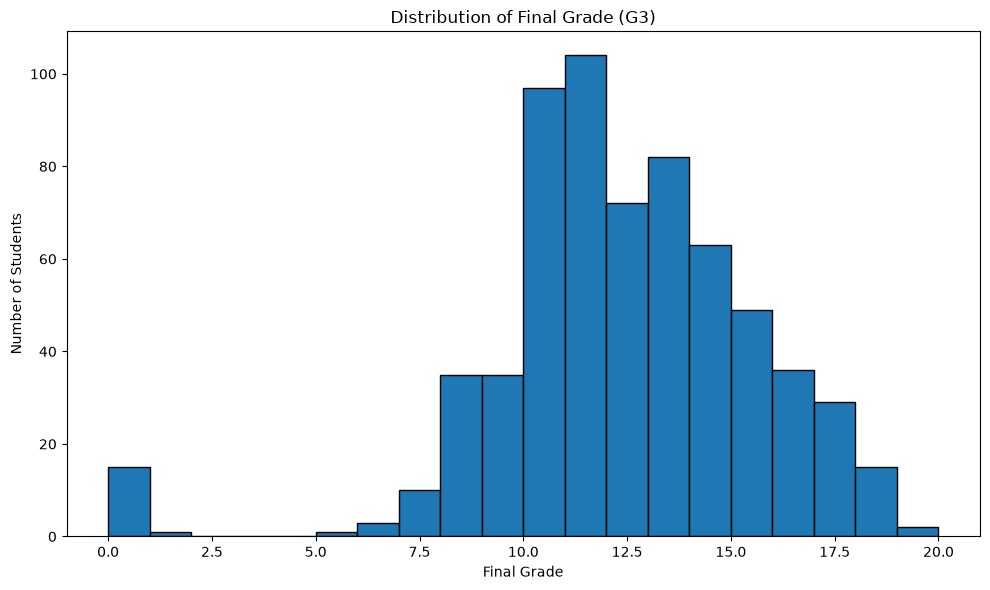

In [4]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["G3"],
    bins=range(
        int(df["G3"].min()),
        int(df["G3"].max()) + 2
    ),
    edgecolor="black"
)

plt.title("Distribution of Final Grade (G3)")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

## 5. At-Risk Classification Target

For the classification experiment, students are categorized according
to their final grade.

The classification target is defined as:

- 0 = At Risk
- 1 = Not At Risk

Students with a final grade below 10 are classified as At Risk, while
students with a final grade of 10 or above are classified as Not At
Risk.

In [5]:
df["at_risk"] = (df["G3"] >= 10).astype(int)

classification_distribution = (
    df["at_risk"]
    .value_counts()
    .rename(index={
        0: "At Risk",
        1: "Not At Risk"
    })
    .to_frame("Count")
)

classification_distribution["Percentage"] = (
    classification_distribution["Count"]
    / len(df)
    * 100
)

classification_distribution

,Count,Percentage
at_risk,,
Not At Risk,549,84.59168
At Risk,100,15.40832


## 6. Regression Analysis Summary

The regression experiment was used to predict the final student grade
(G3) as a continuous numerical outcome.

Multiple regression approaches were evaluated and compared using
appropriate regression metrics, including Mean Absolute Error (MAE),
Root Mean Squared Error (RMSE), R², and cross-validation.

The final evaluation consolidates the regression findings for
comparison with the classification results.

### Regression Model Comparison

Five regression approaches were evaluated for predicting the final
student grade (G3):

1. Linear Regression
2. Decision Tree
3. Decision Tree with maximum depth of 5
4. Random Forest
5. Tuned Random Forest

Model selection was based on five-fold cross-validation using RMSE.
The held-out test set was then used to assess the final selected model.
Lower MAE and RMSE indicate lower prediction error, while higher R²
indicates better explanatory predictive performance.

In [6]:
regression_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Decision Tree (max_depth=5)",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Test MAE": [
        2.156382,
        2.861538,
        2.372037,
        2.050462,
        2.011642
    ],
    "Test RMSE": [
        2.861780,
        3.798785,
        3.159420,
        2.812826,
        2.764395
    ],
    "Test R2": [
        0.160170,
        -0.479818,
        -0.023608,
        0.188657,
        0.216355
    ],
    "Training RMSE": [
        2.539222,
        0.000000,
        2.215129,
        1.010301,
        1.864276
    ],
    "CV RMSE": [
        2.789740,
        3.784113,
        3.198279,
        2.723841,
        2.632484
    ]
})

regression_results

,Model,Test MAE,Test RMSE,Test R2,Training RMSE,CV RMSE
0,Linear Regression,2.156382,2.861780,0.160170,2.539222,2.789740
1,Decision Tree,2.861538,3.798785,-0.479818,0.000000,3.784113
2,Decision Tree (max_depth=5),2.372037,3.159420,-0.023608,2.215129,3.198279
3,Random Forest,2.050462,2.812826,0.188657,1.010301,2.723841
4,Tuned Random Forest,2.011642,2.764395,0.216355,1.864276,2.632484


### Selected Regression Model

The Tuned Random Forest achieved the lowest mean cross-validation RMSE
(2.6325), the lowest test RMSE (2.7644), the lowest test MAE (2.0116),
and the highest test R² (0.2164) among the evaluated regression models.

Therefore, the Tuned Random Forest is selected as the final regression
model for predicting G3.

In [7]:
best_regression_model = regression_results.loc[
    regression_results["CV RMSE"].idxmin()
]

best_regression_model

Model            Tuned Random Forest
Test MAE                    2.011642
Test RMSE                   2.764395
Test R2                     0.216355
Training RMSE               1.864276
CV RMSE                     2.632484
Name: 4, dtype: object

### Regression RMSE Comparison

The following comparison shows the test-set RMSE of the evaluated
regression models. Lower RMSE represents better predictive accuracy.

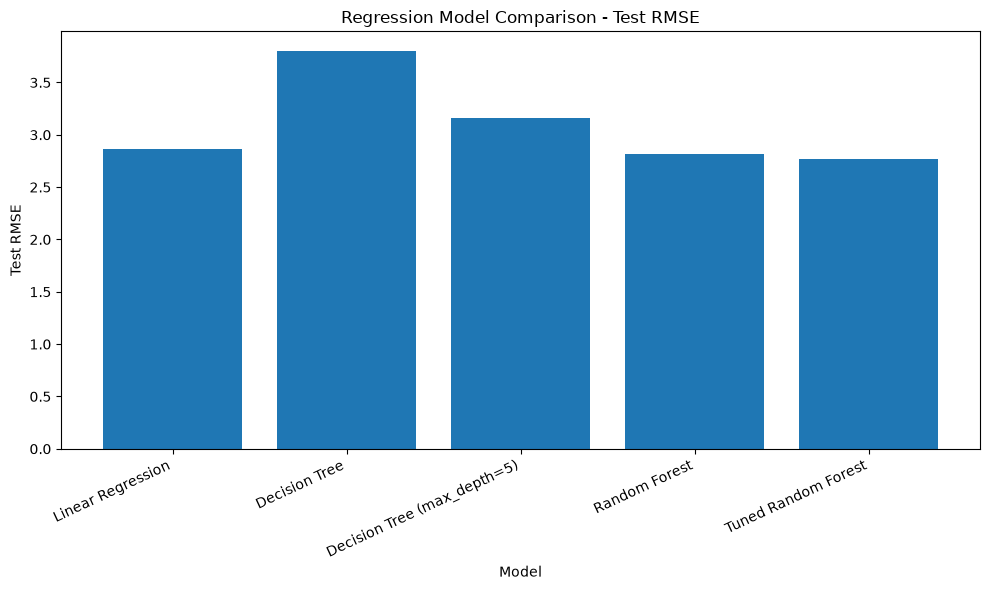

In [8]:
plt.figure(figsize=(10, 6))

plt.bar(
    regression_results["Model"],
    regression_results["Test RMSE"]
)

plt.title("Regression Model Comparison - Test RMSE")
plt.xlabel("Model")
plt.ylabel("Test RMSE")

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()
plt.show()

### Regression Interpretation

The regression results indicate that ensemble-based Random Forest
models performed better than the simpler baseline and tree-based
alternatives.

The unrestricted Decision Tree produced a training RMSE of 0.0000
while its test RMSE increased to 3.7988 and its test R² was negative.
This indicates substantial overfitting.

Restricting the Decision Tree to a maximum depth of 5 reduced the
training error and the degree of overfitting, but its predictive
performance remained weaker than the Random Forest models.

Linear Regression provided a useful baseline with a test RMSE of
2.8618 and an R² of 0.1602.

The initial Random Forest improved upon the baseline, achieving a test
RMSE of 2.8128 and an R² of 0.1887.

The tuned Random Forest achieved the strongest regression performance,
with a test RMSE of 2.7644, MAE of 2.0116, and R² of 0.2164. It also
achieved the lowest mean cross-validation RMSE of 2.6325.

Therefore, the tuned Random Forest was selected as the final regression
model.

### Tuned Random Forest Configuration

The selected Random Forest configuration was obtained through
RandomizedSearchCV using five-fold cross-validation.

In [9]:
tuned_rf_parameters = pd.DataFrame({
    "Parameter": [
        "n_estimators",
        "max_depth",
        "min_samples_split",
        "min_samples_leaf",
        "max_features"
    ],
    "Selected Value": [
        300,
        10,
        2,
        4,
        0.5
    ]
})

tuned_rf_parameters

,Parameter,Selected Value
0,n_estimators,300.0
1,max_depth,10.0
2,min_samples_split,2.0
3,min_samples_leaf,4.0
4,max_features,0.5


### Regression Overfitting and Generalization

The unrestricted Decision Tree provides clear evidence of overfitting.
Its training RMSE was 0.0000, while its test RMSE increased to 3.7988.
This indicates that the model fitted the training observations very
closely but did not generalize well to unseen data.

The tuned Random Forest showed a smaller difference between training,
cross-validation, and test performance:

- Training RMSE: 1.8643
- Cross-validation RMSE: 2.6325
- Test RMSE: 2.7644

Although some generalization gap remains, the tuned Random Forest
generalized substantially better than the unrestricted Decision Tree.

## 7. Regression Conclusion

The regression experiment demonstrated that machine learning can
provide useful predictions of students' final grades using the selected
early student characteristics.

Among the five evaluated approaches, the Tuned Random Forest produced
the strongest overall regression performance.

The model achieved:

- MAE = 2.0116
- RMSE = 2.7644
- R² = 0.2164
- Mean CV RMSE = 2.6325

The results indicate that the model captures some meaningful patterns
in student performance, although the relatively modest R² shows that
the available early student characteristics explain only part of the
variation in final grades.

The regression findings therefore support the use of machine learning
as a predictive aid, but not as a complete explanation of student
academic performance.

# 8. Classification Results

The classification experiment was conducted to identify students who may
be at risk of poor final academic performance.

Three initial classification algorithms were evaluated:

1. Logistic Regression
2. Decision Tree
3. Random Forest

RandomizedSearchCV was subsequently applied to the Random Forest to
investigate whether hyperparameter optimization could improve its
performance.

Because the classification dataset is imbalanced, Macro F1 and
At-Risk Recall are emphasized in addition to overall accuracy.

### Classification results table

In [10]:
classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "CV Macro F1": [
        0.7079,
        0.6697,
        0.7352,
        0.7396
    ],
    "CV At-Risk Recall": [
        0.7375,
        0.4125,
        0.5125,
        0.6000
    ],
    "Test Accuracy": [
        0.6538,
        0.7077,
        0.7615,
        0.7538
    ],
    "Test Macro F1": [
        0.5286,
        0.4982,
        0.5681,
        0.5623
    ],
    "Test At-Risk Recall": [
        0.45,
        0.20,
        0.30,
        0.30
    ],
    "Test At-Risk F1": [
        0.2857,
        0.1739,
        0.2791,
        0.2727
    ]
})

classification_results

,Model,CV Macro F1,CV At-Risk Recall,Test Accuracy,Test Macro F1,Test At-Risk Recall,Test At-Risk F1
0,Logistic Regression,0.7079,0.7375,0.6538,0.5286,0.45,0.2857
1,Decision Tree,0.6697,0.4125,0.7077,0.4982,0.20,0.1739
2,Random Forest,0.7352,0.5125,0.7615,0.5681,0.30,0.2791
3,Tuned Random Forest,0.7396,0.6000,0.7538,0.5623,0.30,0.2727


### Identify the CV winner

In [11]:
best_classification_cv = classification_results.loc[
    classification_results["CV Macro F1"].idxmax()
]

best_classification_cv

Model                  Tuned Random Forest
CV Macro F1                         0.7396
CV At-Risk Recall                      0.6
Test Accuracy                       0.7538
Test Macro F1                       0.5623
Test At-Risk Recall                    0.3
Test At-Risk F1                     0.2727
Name: 3, dtype: object

## Classification Interpretation

The tuned Random Forest achieved the highest cross-validation Macro
F1-score (0.7396) among the evaluated classification models and was
therefore selected as the preferred overall classifier based on
cross-validation.

The original Random Forest achieved the highest held-out test accuracy
(76.15%) and the highest test Macro F1-score (0.5681). The tuned Random
Forest achieved slightly lower test accuracy (75.38%) and Macro F1
(0.5623).

This difference demonstrates that the model selected using
cross-validation does not necessarily achieve the highest score on a
single held-out test set.

Logistic Regression achieved the strongest At-Risk recall on the
held-out test set at 45%. It also achieved the highest cross-validation
At-Risk recall among the initial classification models.

Therefore, the tuned Random Forest is selected as the overall
classification model, while Logistic Regression is identified as a
useful alternative when the primary objective is detecting as many
At-Risk students as possible.

## Classification Model Comparison

The following chart compares the Macro F1-score of the evaluated
classification models on the held-out test set.

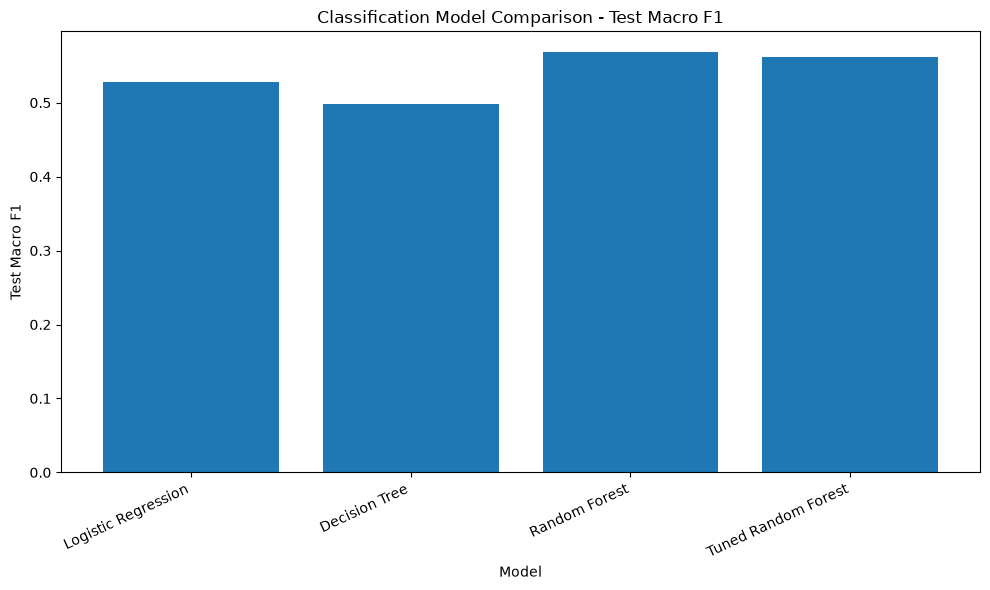

In [12]:
plt.figure(figsize=(10, 6))

plt.bar(
    classification_results["Model"],
    classification_results["Test Macro F1"]
)

plt.title("Classification Model Comparison - Test Macro F1")
plt.xlabel("Model")
plt.ylabel("Test Macro F1")

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()
plt.show()

## At-Risk Detection Comparison

At-Risk Recall measures the proportion of genuinely At-Risk students
that are correctly identified by the classifier.

A higher recall is desirable when the objective is to identify students
who may require additional academic support.

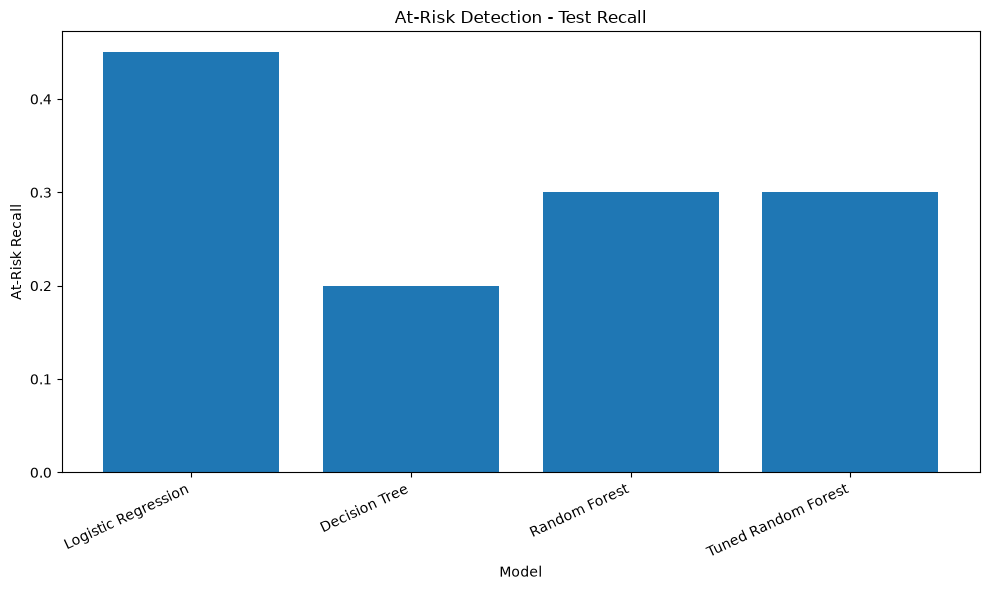

In [13]:
plt.figure(figsize=(10, 6))

plt.bar(
    classification_results["Model"],
    classification_results["Test At-Risk Recall"]
)

plt.title("At-Risk Detection - Test Recall")
plt.xlabel("Model")
plt.ylabel("At-Risk Recall")

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()
plt.show()

## Classification Conclusion

The classification experiment demonstrates that machine learning can
identify patterns associated with students who may be at risk of poor
final academic performance.

The Tuned Random Forest achieved the strongest cross-validation Macro
F1-score and was selected as the overall classification model based on
cross-validation.

However, Logistic Regression achieved the highest At-Risk recall on the
held-out test set, correctly identifying 45% of students belonging to
the At-Risk class.

The results therefore demonstrate a trade-off between overall
classification performance and sensitivity toward the minority
At-Risk class.

For a general-purpose classification system, the Tuned Random Forest
provides the preferred overall model. For an early-warning scenario
where identifying potentially At-Risk students is more important than
overall accuracy, Logistic Regression provides a useful alternative.

# 9. Overall Model Comparison

The regression and classification experiments address different
prediction objectives and therefore use different evaluation metrics.

Regression predicts the continuous final grade (G3), while
classification predicts whether a student belongs to the At-Risk or
Not At-Risk category.

The following summary identifies the selected model for each task.

In [14]:
final_model_summary = pd.DataFrame({
    "Task": [
        "Regression",
        "Classification",
        "Classification - At-Risk Detection"
    ],
    "Selected Model": [
        "Tuned Random Forest",
        "Tuned Random Forest",
        "Logistic Regression"
    ],
    "Primary Metric": [
        "Cross-validation RMSE",
        "Cross-validation Macro F1",
        "At-Risk Recall"
    ],
    "Result": [
        2.6325,
        0.7396,
        0.7375
    ],
    "Interpretation": [
        "Lowest CV RMSE",
        "Highest CV Macro F1",
        "Highest At-Risk recall among initial classifiers"
    ]
})

final_model_summary

,Task,Selected Model,Primary Metric,Result,Interpretation
0,Regression,Tuned Random Forest,Cross-validation RMSE,2.6325,Lowest CV RMSE
1,Classification,Tuned Random Forest,Cross-validation Macro F1,0.7396,Highest CV Macro F1
2,Classification - At-Risk Detection,Logistic Regression,At-Risk Recall,0.7375,Highest At-Risk recall among initial classifiers


## Overall Findings

The project produced two complementary machine learning outcomes.

For regression, the Tuned Random Forest was selected because it achieved
the lowest mean cross-validation RMSE of 2.6325. On the held-out test
set it achieved an MAE of 2.0116, RMSE of 2.7644, and R² of 0.2164.

For classification, the Tuned Random Forest achieved the highest
cross-validation Macro F1-score of 0.7396 and was selected as the
overall classifier. Its held-out test accuracy was 75.38% and its test
Macro F1-score was 0.5623.

However, Logistic Regression demonstrated greater sensitivity toward
the At-Risk class, achieving an At-Risk recall of 45% on the held-out
test set.

These results suggest that student performance prediction and student
risk identification should be considered related but distinct
machine learning tasks. A model that performs strongly overall does not
necessarily provide the highest sensitivity for the minority At-Risk
group.

# 10. Important Predictive Features

Feature importance from the selected Random Forest classification model
is examined to identify the transformed student characteristics that
contribute most strongly to the classification predictions.

Because categorical variables were one-hot encoded during preprocessing,
the feature importance values correspond to the transformed feature
representation.

In [15]:
# Recreate the selected Tuned Random Forest model
# using the exact configuration selected in 03_classification.ipynb.

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

# Classification features
X_classification = features.copy()

# Final-grade classification target
# 0 = At Risk (G3 < 10)
# 1 = Not At Risk (G3 >= 10)
y_classification = (
    targets["G3"] >= 10
).astype(int)

# Same train-test split used in the classification experiment
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_classification,
    y_classification,
    test_size=0.20,
    random_state=42,
    stratify=y_classification
)

# Identify feature types
numeric_features_final = X_classification.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features_final = X_classification.select_dtypes(
    include=["object", "string"]
).columns.tolist()

# Numerical preprocessing
numeric_transformer_final = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# Categorical preprocessing
categorical_transformer_final = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

# Combined preprocessing
preprocessor_final = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer_final,
            numeric_features_final
        ),
        (
            "cat",
            categorical_transformer_final,
            categorical_features_final
        )
    ]
)

# Exact best Random Forest configuration from 03_classification.ipynb
tuned_rf_classifier = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_final
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                max_depth=20,
                min_samples_split=5,
                min_samples_leaf=1,
                max_features="log2",
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Fit the selected model
tuned_rf_classifier.fit(
    X_train_final,
    y_train_final
)

print("Tuned Random Forest recreated successfully.")

Tuned Random Forest recreated successfully.


In [16]:
rf_preprocessor = tuned_rf_classifier.named_steps[
    "preprocessor"
]

rf_model = tuned_rf_classifier.named_steps[
    "model"
]

feature_names = rf_preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

feature_importance.head(15)

,Feature,Importance
0,num__failures,0.101574
1,cat__school_GP,0.071332
2,cat__school_MS,0.066677
3,cat__higher_no,0.048554
4,cat__higher_yes,0.043440
5,num__absences,0.039860
6,num__Medu,0.036699
7,num__goout,0.034551
8,num__Walc,0.033504
9,num__Fedu,0.033174


### Feature Importance Visualization

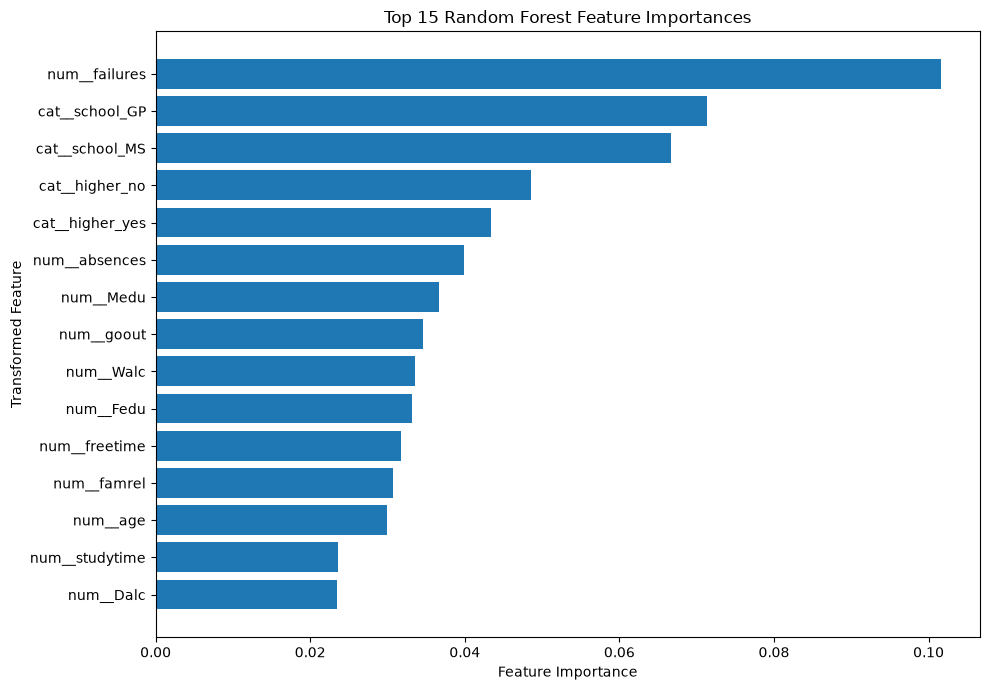

In [17]:
top_features = feature_importance.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Feature Importance")
plt.ylabel("Transformed Feature")

plt.tight_layout()
plt.show()

# 11. Key Research Findings

The experiments produced several important findings.

### Finding 1 — Machine learning can identify useful performance patterns

The regression and classification experiments demonstrate that student
demographic, academic, family, social, and lifestyle characteristics
contain predictive information related to academic performance.

### Finding 2 — Tuned Random Forest performed strongly overall

The Tuned Random Forest was selected for both regression and overall
classification based on cross-validation performance.

For regression, it achieved a mean cross-validation RMSE of 2.6325.

For classification, it achieved a mean cross-validation Macro F1-score
of 0.7396.

### Finding 3 — At-Risk detection remains difficult

Although the overall classification performance was reasonable,
identification of the minority At-Risk class remained challenging.

Logistic Regression achieved the highest At-Risk recall on the held-out
test set at 45%.

### Finding 4 — Model selection depends on the objective

The model with the strongest overall performance is not necessarily
the model with the highest sensitivity toward At-Risk students.

Therefore, model selection should consider the intended application
rather than accuracy alone.

### Finding 5 — Early prediction has limitations

The classification experiment intentionally excludes G1 and G2 from
the primary predictive features so that the model represents an early
prediction scenario.

This means the available information is limited compared with a model
that uses later academic grades.

# 12. Project Limitations

Several limitations should be considered when interpreting the results.

1. The dataset contains only 649 student records, which limits the
   amount of information available for training and evaluating complex
   machine learning models.

2. The At-Risk class is a minority class, which makes reliable
   identification of At-Risk students more difficult.

3. The classification experiment excludes G1 and G2 from the primary
   prediction features to support an early-warning scenario.

4. The relatively modest regression R² indicates that the available
   features explain only a limited proportion of the variation in final
   grades.

5. The classification models do not identify all At-Risk students.
   Therefore, predictions should not be interpreted as definitive
   assessments of student performance.

6. Student academic performance can be influenced by many factors that
   are not represented in the available dataset.

7. The results are based on a single dataset and should be validated on
   additional student populations before being used in a real-world
   educational intervention system.

# 13. Final Research Conclusion

This project investigated whether machine learning techniques can use
student demographic, academic, family, social, and lifestyle
characteristics to predict academic performance and identify students
who may be at risk of poor final academic performance.

Two complementary machine learning tasks were investigated.

For regression, five approaches were compared. The Tuned Random Forest
achieved the strongest performance, with a mean cross-validation RMSE
of 2.6325, test MAE of 2.0116, test RMSE of 2.7644, and test R² of
0.2164.

For classification, Logistic Regression, Decision Tree, Random Forest,
and a Tuned Random Forest were evaluated. The Tuned Random Forest
achieved the highest cross-validation Macro F1-score of 0.7396 and was
selected as the overall classification model.

However, Logistic Regression achieved the highest At-Risk recall on
the held-out test set at 45%. This demonstrates an important trade-off
between overall classification performance and sensitivity toward
students who may require additional support.

The results provide evidence that machine learning can identify useful
patterns in student data. However, the moderate regression R² and
limited At-Risk recall indicate that the available features are not
sufficient to provide highly reliable predictions for every student.

Overall, the project demonstrates the potential of educational data
mining and machine learning as decision-support tools for early
identification of academic risk. Future work could investigate larger
datasets, additional educational and behavioural variables, improved
class-imbalance techniques, and alternative machine learning models.

# 14. Final Summary

| Area | Selected Model / Finding |
|---|---|
| Regression | Tuned Random Forest |
| Regression CV RMSE | 2.6325 |
| Regression Test RMSE | 2.7644 |
| Regression Test MAE | 2.0116 |
| Regression Test R² | 0.2164 |
| Overall Classification | Tuned Random Forest |
| Classification CV Macro F1 | 0.7396 |
| Classification Test Accuracy | 75.38% |
| Classification Test Macro F1 | 0.5623 |
| Best At-Risk Recall | Logistic Regression |
| At-Risk Test Recall | 45% |

The findings provide the experimental foundation for the Results,
Discussion, and Conclusion sections of the final project report.